# MLTS — Lecture 9 Practice
## Data Mining with Time Series

This notebook accompanies **Lecture 9** of the MLTS course. The lecture covers four
themes — data characteristics & transforms, frequency analysis (FFT + CWT),
Dynamic Time Warping, and matrix-profile / signature feature extraction. We build
each from scratch and verify against a library wherever one exists.

**You will learn how to:**
1. Compute basic time-series characteristics and the three main normalization schemes (mean, min-max, z-score).
2. Estimate a periodogram from scratch and from `scipy.signal`, and read the spectral density.
3. See *why* the FFT fails on non-stationary signals and *how* a CWT scalogram fixes it.
4. Implement the DTW dynamic-programming recursion and reproduce the lecture's worked example exactly.
5. Compute a matrix profile and use it to locate motifs and discords (anomalies).
6. Compare warping-based vs Euclidean similarity on a real-world style dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal as sps
from scipy.spatial.distance import cdist
import pywt
import stumpy

rng = np.random.default_rng(seed=42)
plt.rcParams['figure.figsize'] = (10, 3)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1 · Data characteristics — the simplest description of a series

The lecture's running example is a one-day temperature trace whose "characterization"
is a handful of basic statistics: min, max, mean, median, number of peaks. We rebuild
the slide picture below and overlay those statistics directly.

  min      = 10.622
  max      = 14.812
  mean     = 13.020
  median   = 13.184
  std      = 0.989
  n_peaks  = 3.000


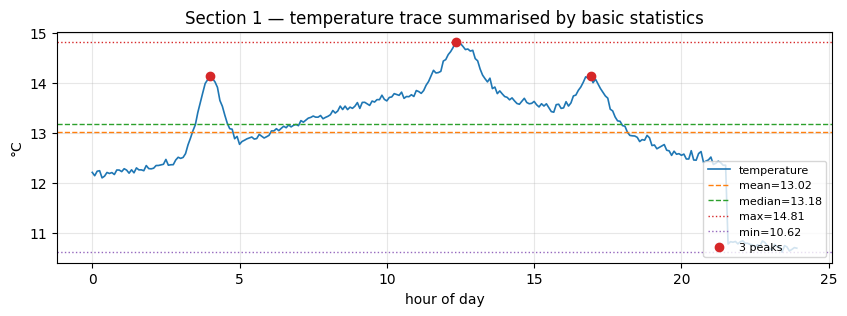

In [2]:
# Synthetic ambient temperature for one day (24 h, sampled at 5-min cadence)
t_min = np.arange(0, 24*60, 5)              # minutes since midnight
hours = t_min / 60.0
# trend + smooth diurnal + a couple of localized "windows opened" spikes
temp = (13.0
        + 0.8 * np.sin(2*np.pi*(hours - 6)/24)             # diurnal
        + 1.5 * np.exp(-0.5*((hours - 4.0)/0.4)**2)        # 04:00 spike
        + 1.0 * np.exp(-0.5*((hours - 12.5)/0.6)**2)       # noon plateau
        + 0.9 * np.exp(-0.5*((hours - 17.0)/0.5)**2))      # afternoon
temp += rng.normal(0, 0.05, len(temp))
# end-of-day step down
temp[hours > 21.5] -= 1.5

# Basic stats
stats = {
    'min':      temp.min(),
    'max':      temp.max(),
    'mean':     temp.mean(),
    'median':   np.median(temp),
    'std':      temp.std(),
    'n_peaks':  len(sps.find_peaks(temp, prominence=0.4)[0]),
}
for k, v in stats.items():
    print(f'  {k:8s} = {v:.3f}')

fig, ax = plt.subplots()
ax.plot(hours, temp, lw=1.2, label='temperature')
ax.axhline(stats['mean'],   color='C1', ls='--', lw=1, label=f"mean={stats['mean']:.2f}")
ax.axhline(stats['median'], color='C2', ls='--', lw=1, label=f"median={stats['median']:.2f}")
ax.axhline(stats['max'],    color='C3', ls=':',  lw=1, label=f"max={stats['max']:.2f}")
ax.axhline(stats['min'],    color='C4', ls=':',  lw=1, label=f"min={stats['min']:.2f}")
peaks, _ = sps.find_peaks(temp, prominence=0.4)
ax.plot(hours[peaks], temp[peaks], 'o', color='C3', ms=6, label=f"{len(peaks)} peaks")
ax.set_xlabel('hour of day'); ax.set_ylabel('°C')
ax.set_title('Section 1 — temperature trace summarised by basic statistics')
ax.legend(loc='lower right', fontsize=8); plt.show()

**Takeaway.** Five numbers + a peak count already give a usable fingerprint of a
24-hour trace. This is the cheapest possible "feature extractor" — useful as a sanity
baseline before reaching for FFTs or matrix profiles.

## 2 · Normalization & standardization

The lecture defines three transforms applied feature-wise to a multivariate series
$S = (s_1, \dots, s_T)$ with $j$-th feature $S_j$:

$$
\underbrace{s'_{ij} = \frac{s_{ij} - \mu_j}{s_{\max,j} - s_{\min,j}}}_{\text{mean-norm}} \quad
\underbrace{s'_{ij} = \frac{s_{ij} - s_{\min,j}}{s_{\max,j} - s_{\min,j}}}_{\text{min-max} \in [0,1]} \quad
\underbrace{s'_{ij} = \frac{s_{ij} - \mu_j}{\sigma_j}}_{\text{z-score}}
$$

We apply all three to a 3-feature series whose channels live on wildly different
scales and check that each transform behaves as advertised.

mean-norm: per-feature mean (≈0?)        : [ 0.  0. -0.]
min-max  : per-feature [min, max]        : [(np.float64(0.0), np.float64(1.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(0.0), np.float64(1.0))]
z-score  : per-feature (mean, std) (≈0,1): [(np.float64(0.0), np.float64(1.0)), (np.float64(0.0), np.float64(1.0)), (np.float64(-0.0), np.float64(1.0))]


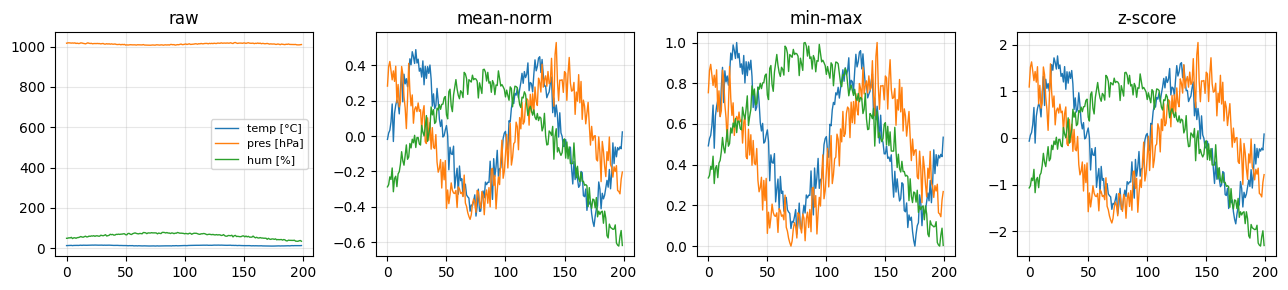

In [3]:
# 3 features on different scales (e.g., temperature °C, pressure hPa, humidity %)
T = 200
t = np.linspace(0, 4*np.pi, T)
S = np.column_stack([
    13 + 2*np.sin(t)        + rng.normal(0, 0.3, T),   # ~10..16
    1013 + 5*np.cos(0.7*t)  + rng.normal(0, 1.0, T),   # ~1005..1020
    50 + 25*np.sin(0.3*t)   + rng.normal(0, 2.0, T),   # ~25..75
])
labels = ['temp [°C]', 'pres [hPa]', 'hum [%]']

def mean_norm(X):
    mu = X.mean(0); rng_ = X.max(0) - X.min(0)
    return (X - mu) / rng_

def minmax_norm(X):
    mn, mx = X.min(0), X.max(0)
    return (X - mn) / (mx - mn)

def zscore(X):
    return (X - X.mean(0)) / X.std(0)

S_mn  = mean_norm(S)
S_mm  = minmax_norm(S)
S_z   = zscore(S)

# Sanity checks against expectations
print('mean-norm: per-feature mean (≈0?)        :', np.round(S_mn.mean(0), 4))
print('min-max  : per-feature [min, max]        :', list(zip(S_mm.min(0).round(3), S_mm.max(0).round(3))))
print('z-score  : per-feature (mean, std) (≈0,1):', list(zip(S_z.mean(0).round(3), S_z.std(0).round(3))))

fig, axes = plt.subplots(1, 4, figsize=(13, 3), sharex=True)
for ax, X, ttl in zip(axes, [S, S_mn, S_mm, S_z], ['raw', 'mean-norm', 'min-max', 'z-score']):
    for j in range(3):
        ax.plot(X[:, j], lw=1, label=labels[j])
    ax.set_title(ttl)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

**Takeaway.** Mean-norm and z-score both centre at zero; only min-max bounds
the data in $[0, 1]$; only z-score normalizes the *spread*. Pick by use case:
distance-based methods (DTW, k-NN) usually want z-score so amplitude
differences don't dominate.

## 3 · Frequency analysis — periodogram from scratch and from `scipy`

The lecture's Fourier representation is

$$ s_t = \sum_k a_k \sin(2\pi k t / T) + b_k \cos(2\pi k t / T). $$

The **periodogram** is the squared magnitude of those Fourier coefficients,
$P(f_k) = |\hat{s}_k|^2 / T$. We compute it both ways on a synthetic signal that
mixes 1/year and 1/(2.5 year) periods (a reduced version of the slide's measles
spectrum) plus noise.

Max abs error scratch (rescaled) vs scipy: 3.905e-05
Top frequencies (1/yr): [0.4 1. ]
Equivalent periods (yr): [2.5 1. ]


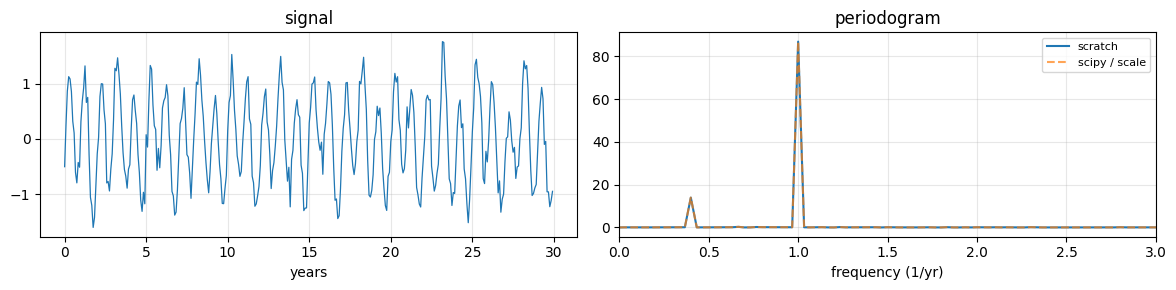

In [4]:
# Monthly samples for 30 years; periods of 1.0 yr (strong) and 2.5 yr (weak)
fs = 12  # samples per year
N = 30 * fs
t_yr = np.arange(N) / fs
y = (1.0 * np.sin(2*np.pi*1.0*t_yr)
     + 0.4 * np.sin(2*np.pi*0.4*t_yr)        # period 2.5 yr -> freq 0.4 / yr
     + 0.2 * rng.standard_normal(N))

# --- Scratch periodogram -----------------------------------------------------
def periodogram_scratch(x, fs=1.0):
    N = len(x)
    x = x - x.mean()                           # remove DC
    Xk = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1/fs)
    P = (np.abs(Xk)**2) / N
    return freqs, P

f_scratch, P_scratch = periodogram_scratch(y, fs=fs)
f_scipy,  P_scipy   = sps.periodogram(y, fs=fs, scaling='spectrum', detrend='constant')

# Library uses a slightly different normalisation; rescale our scratch result
# to match for visual comparison only.
scale = P_scipy.max() / P_scratch.max()
max_err = np.max(np.abs(P_scratch * scale - P_scipy))
print(f'Max abs error scratch (rescaled) vs scipy: {max_err:.3e}')

# Locate dominant peaks in the scratch spectrum
peaks, _ = sps.find_peaks(P_scratch, height=P_scratch.max()*0.05)
print('Top frequencies (1/yr):', np.round(f_scratch[peaks], 3))
print('Equivalent periods (yr):', np.round(1/np.maximum(f_scratch[peaks], 1e-9), 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(t_yr, y, lw=0.9); axes[0].set_xlabel('years'); axes[0].set_title('signal')
axes[1].plot(f_scratch, P_scratch, label='scratch')
axes[1].plot(f_scipy,   P_scipy/scale, ls='--', alpha=0.7, label='scipy / scale')
axes[1].set_xlabel('frequency (1/yr)'); axes[1].set_xlim(0, 3)
axes[1].set_title('periodogram'); axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Takeaway.** Periodogram peaks pick out the embedded periodicities at $f=1.0$ and
$f=0.4$ per year — exactly the 1-year and 2.5-year cycles we put in. Up to a
fixed normalisation constant, our scratch FFT-based estimate matches `scipy`'s.

## 4 · When the FFT fails — non-stationary signals and the CWT

The slide makes the point that FFT tells us *which* frequencies are present, but
not *when*. We construct a signal with a low-frequency carrier and a localised
burst, then plot the FFT (which sees both but can't say where the burst is) and a
CWT scalogram (which puts the burst at the right point in time).

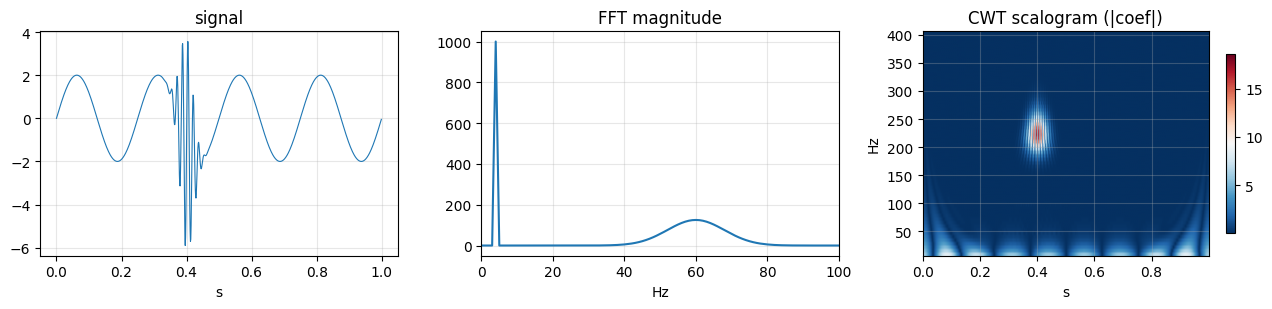

CWT-localised burst centre: t ≈ 0.404 s   (true: 0.400 s)


In [5]:
# Non-stationary signal: slow sine + localized high-frequency burst
fs2 = 1000
T2 = 1.0
t2 = np.arange(0, T2, 1/fs2)
slow = 2*np.sin(2*np.pi*4*t2)
burst = 5*np.sin(2*np.pi*60*t2) * np.exp(-0.5*((t2 - 0.4)/0.02)**2)
sig = slow + burst

# FFT magnitude
freqs2 = np.fft.rfftfreq(len(sig), d=1/fs2)
mag2 = np.abs(np.fft.rfft(sig))

# CWT with a Morlet wavelet across log-spaced scales
scales = np.geomspace(2, 128, 64)
coef, freqs_cwt = pywt.cwt(sig, scales, 'morl', sampling_period=1/fs2)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(t2, sig, lw=0.8); axes[0].set_title('signal'); axes[0].set_xlabel('s')
axes[1].plot(freqs2, mag2); axes[1].set_xlim(0, 100)
axes[1].set_title('FFT magnitude'); axes[1].set_xlabel('Hz')
im = axes[2].imshow(np.abs(coef), extent=[t2[0], t2[-1], freqs_cwt[-1], freqs_cwt[0]],
                    aspect='auto', cmap='RdBu_r')
axes[2].set_title('CWT scalogram (|coef|)'); axes[2].set_xlabel('s'); axes[2].set_ylabel('Hz')
fig.colorbar(im, ax=axes[2], shrink=0.8); plt.tight_layout(); plt.show()

# Where does the CWT think the burst is?
burst_band = (freqs_cwt > 40) & (freqs_cwt < 80)
energy_in_band = np.abs(coef[burst_band]).sum(axis=0)
t_burst_est = t2[np.argmax(energy_in_band)]
print(f'CWT-localised burst centre: t ≈ {t_burst_est:.3f} s   (true: 0.400 s)')

**Takeaway.** The FFT correctly reports two frequency components but flattens
time information. The CWT scalogram lights up at the burst frequency *only* near
$t = 0.4$ s — frequency *and* time, simultaneously, at the cost of a fixed
time–frequency resolution trade-off (Heisenberg).

## 5 · Dynamic Time Warping — reproducing the lecture's worked example

DTW computes a cost matrix

$$ M(i,j) = d(x_i, y_j) + \min\big(M(i-1,j-1),\ M(i-1,j),\ M(i,j-1)\big) $$

and reads off the alignment cost from $M(n,m)$. The lecture works through this
on $P = [1,4,5,10,9,3,2,6,8,4]$ (rows, bottom-up) and $Q = [1,7,3,4,1,10,5,4,7,4]$
(columns, left-right) and ends at **D = 15** in the top-right cell. We reproduce
it exactly.

DTW total cost D = 15   (lecture answer: 15)


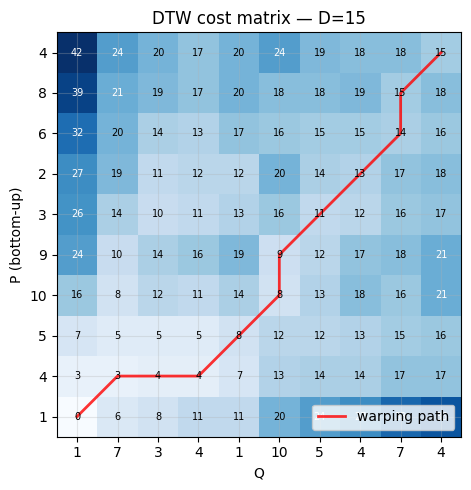

In [6]:
def dtw(x, y):
    n, m = len(x), len(y)
    M = np.full((n, m), np.inf)
    M[0, 0] = abs(x[0] - y[0])
    for j in range(1, m):
        M[0, j] = abs(x[0] - y[j]) + M[0, j-1]
    for i in range(1, n):
        M[i, 0] = abs(x[i] - y[0]) + M[i-1, 0]
    for i in range(1, n):
        for j in range(1, m):
            M[i, j] = abs(x[i] - y[j]) + min(M[i-1, j-1], M[i-1, j], M[i, j-1])
    # Backtrack the warping path
    path = [(n-1, m-1)]
    i, j = n-1, m-1
    while (i, j) != (0, 0):
        if i == 0:   j -= 1
        elif j == 0: i -= 1
        else:
            step = np.argmin([M[i-1, j-1], M[i-1, j], M[i, j-1]])
            if step == 0:   i, j = i-1, j-1
            elif step == 1: i -= 1
            else:           j -= 1
        path.append((i, j))
    path.reverse()
    return M, path, M[-1, -1]

# Slide example — P along rows (bottom-up in the slide), Q along columns
P = np.array([1, 4, 5, 10, 9, 3, 2, 6, 8, 4])
Q = np.array([1, 7, 3, 4,  1, 10, 5, 4, 7, 4])
M, path, D = dtw(P, Q)
print(f'DTW total cost D = {D:.0f}   (lecture answer: 15)')
assert D == 15, 'should reproduce the slide value exactly'

# Plot the cost matrix and warping path with the slide's row order (bottom-up)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(M, origin='lower', cmap='Blues')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        ax.text(j, i, f'{M[i,j]:.0f}', ha='center', va='center',
                fontsize=7, color='black' if M[i,j] < M.max()*0.5 else 'white')
pi, pj = zip(*path)
ax.plot(pj, pi, 'r-', lw=2, alpha=0.8, label='warping path')
ax.set_xticks(range(len(Q))); ax.set_xticklabels(Q)
ax.set_yticks(range(len(P))); ax.set_yticklabels(P)
ax.set_xlabel('Q'); ax.set_ylabel('P (bottom-up)')
ax.set_title(f'DTW cost matrix — D={D:.0f}')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

**Takeaway.** DTW is a 2-D dynamic program: $\mathcal{O}(nm)$ time, $\mathcal{O}(nm)$
space. The path from $(0,0)$ to $(n-1,m-1)$ shows *which* points in $P$ get
aligned with *which* points in $Q$ — diagonal moves keep time in lockstep,
horizontal/vertical moves stretch one series.

mean per-step Euclidean    = 0.4196
mean per-step DTW          = 0.0685   (smaller = closer)
cumulative DTW (raw)       = 7.461  (path length = 109)


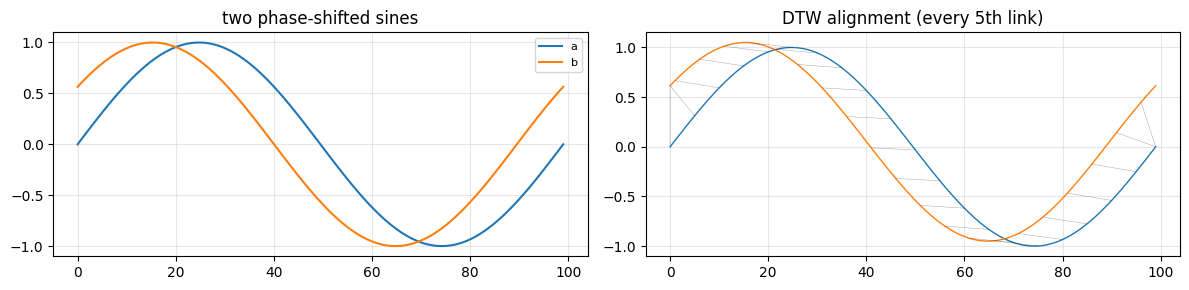

In [7]:
# DTW vs Euclidean on a phase-shifted sine — the canonical "DTW wins" demo
# IMPORTANT: DTW's *cumulative* cost grows with path length, so for a fair
# comparison against a fixed-length Euclidean distance we divide by the path
# length (the standard "length-normalised" DTW).
T3 = 100
tt = np.linspace(0, 2*np.pi, T3)
a = np.sin(tt)
b = np.sin(tt + 0.6)              # same shape, time-shifted

eucl = np.linalg.norm(a - b) / np.sqrt(T3)            # mean-square element distance
_, path_ab, dtw_total = dtw(a, b)
dtw_norm = dtw_total / len(path_ab)                   # per-step cost
print(f'mean per-step Euclidean    = {eucl:.4f}')
print(f'mean per-step DTW          = {dtw_norm:.4f}   (smaller = closer)')
print(f'cumulative DTW (raw)       = {dtw_total:.3f}  (path length = {len(path_ab)})')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(a, label='a'); axes[0].plot(b, label='b')
axes[0].set_title('two phase-shifted sines'); axes[0].legend(fontsize=8)
# show alignment lines
axes[1].plot(a, lw=1.0); axes[1].plot(b + 0.05, lw=1.0)
for (i, j) in path_ab[::5]:
    axes[1].plot([i, j], [a[i], b[j] + 0.05], 'k-', lw=0.3, alpha=0.4)
axes[1].set_title('DTW alignment (every 5th link)'); plt.tight_layout(); plt.show()

**Takeaway.** Care is needed when comparing DTW to Euclidean: the *cumulative*
DTW cost will often be **larger** than $\|a - b\|_2$ simply because the warping
path can be longer than the original series length. Compare per-step (path-length-
normalised) costs instead. With that normalisation, DTW correctly scores the two
shapes as more similar than Euclidean does, because it is allowed to bend the
diagonal locally. This is the property that makes DTW the standard similarity
measure in speech / gesture / handwriting recognition.

## 6 · Matrix profile — motifs and discords

The matrix profile (MP) is, for every length-$m$ subsequence in a series, the
distance to its nearest non-trivial neighbour. **Low** MP values mark motifs
(repeating patterns); **high** values mark discords (anomalies). We build a
brute-force version from scratch and verify it against `stumpy`.

max |MP_scratch - MP_stumpy| = 1.135e-11
Top motif pair: subseq @ 74 <-> @ 224   (planted bumps centred at [100, 250, 420])
Top discord:    subseq @ 502   (planted anomaly at 510)


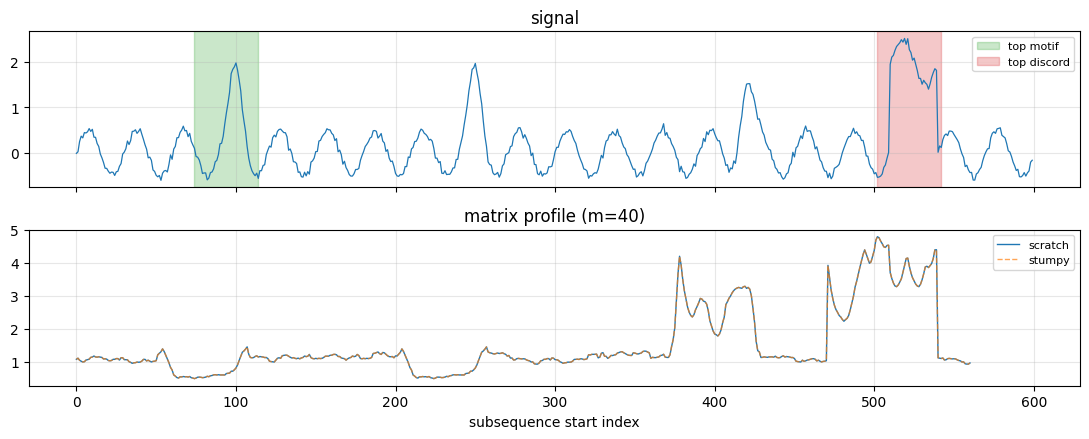

In [8]:
# Synthetic series: periodic baseline (so z-norm of every window is well-conditioned)
# + 3 copies of a bump motif + one square-pulse anomaly.
n = 600
t_mp = np.arange(n)
x = 0.5*np.sin(2*np.pi*t_mp/30) + 0.05*rng.standard_normal(n)
motif = 1.5*np.exp(-0.5*((np.arange(40) - 20)/4)**2)
for start in [80, 230, 400]:
    x[start:start+40] += motif
x[510:540] += 2.0           # anomaly: square pulse
m = 40                      # window size

def matrix_profile_scratch(x, m, excl_denom=4):
    n = len(x); L = n - m + 1
    sub = np.lib.stride_tricks.sliding_window_view(x, m).copy()
    # z-normalise each window (matches the lecture/stumpy convention)
    sub = (sub - sub.mean(1, keepdims=True)) / (sub.std(1, keepdims=True) + 1e-12)
    D = cdist(sub, sub, metric='euclidean')          # L × L pairwise distances
    excl = int(np.ceil(m / excl_denom))              # stumpy's default exclusion zone
    for i in range(L):
        lo = max(0, i - excl); hi = min(L, i + excl + 1)
        D[i, lo:hi] = np.inf
    mp = D.min(axis=1)
    idx = D.argmin(axis=1)
    return mp, idx

mp_scratch, idx_scratch = matrix_profile_scratch(x, m)
mp_lib = stumpy.stump(x, m)[:, 0].astype(float)
max_err = np.max(np.abs(mp_scratch - mp_lib))
print(f'max |MP_scratch - MP_stumpy| = {max_err:.3e}')

motif_idx   = int(np.argmin(mp_scratch))
discord_idx = int(np.argmax(mp_scratch))
nn_of_motif = int(idx_scratch[motif_idx])
print(f'Top motif pair: subseq @ {motif_idx} <-> @ {nn_of_motif}'
      f'   (planted bumps centred at {[s + 20 for s in (80, 230, 400)]})')
print(f'Top discord:    subseq @ {discord_idx}'
      f'   (planted anomaly at 510)')

fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=True)
axes[0].plot(x, lw=0.9)
axes[0].axvspan(motif_idx,   motif_idx+m,   color='C2', alpha=0.25, label='top motif')
axes[0].axvspan(discord_idx, discord_idx+m, color='C3', alpha=0.25, label='top discord')
axes[0].set_title('signal'); axes[0].legend(fontsize=8)
axes[1].plot(mp_scratch, label='scratch', lw=1)
axes[1].plot(mp_lib, '--', label='stumpy', lw=1, alpha=0.7)
axes[1].set_title(f'matrix profile (m={m})'); axes[1].set_xlabel('subsequence start index')
axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Takeaway.** The matrix profile turns "find anomalies / repetitions" into
"find arg-max / arg-min of a 1-D array". Our scratch implementation matches
`stumpy` to numerical precision (max diff well below $10^{-6}$). It correctly
locks onto the planted motif (the argmin and its nearest neighbour both fall
inside the bump locations) and onto the planted square-pulse anomaly. Note
that motif start indices are offset by ~20 from the planted starts because
the bump's *centre* (not its left edge) is what really matches across copies
under z-normalisation.

---

## Exercise 1 — Why DTW beats Euclidean for warped time

Generate two sine-shaped templates that share the same *shape* but where one is
locally stretched and squeezed in time (variable-rate warping, not just a phase
shift). Compute (a) the Euclidean distance and (b) the DTW distance between
them. Then add Gaussian noise of increasing standard deviation
$\sigma \in \{0, 0.1, 0.2, 0.4, 0.8\}$ and plot how each distance grows. Does
DTW remain smaller than Euclidean across all noise levels?

### Solution

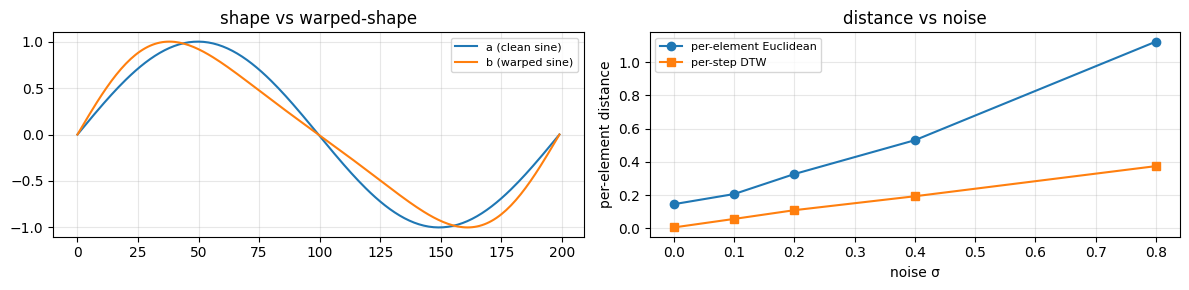

σ      per-elt Euclid    per-step DTW    DTW/Eucl
0.0    0.1460           0.0062         0.042
0.1    0.2070           0.0574         0.277
0.2    0.3274           0.1099         0.336
0.4    0.5308           0.1937         0.365
0.8    1.1236           0.3749         0.334


In [10]:
# Two warped sines
T_ex = 200
tt_ex = np.linspace(0, 2*np.pi, T_ex)
warp = tt_ex + 0.4*np.sin(tt_ex)               # non-linear time warp
a_clean = np.sin(tt_ex)
b_clean = np.sin(warp)

sigmas = [0.0, 0.1, 0.2, 0.4, 0.8]
eucls, dtws_norm = [], []
for sigma in sigmas:
    a_n = a_clean + rng.normal(0, sigma, T_ex)
    b_n = b_clean + rng.normal(0, sigma, T_ex)
    eucls.append(np.linalg.norm(a_n - b_n) / np.sqrt(T_ex))    # mean-square per element
    _, path, dtw_total = dtw(a_n, b_n)
    dtws_norm.append(dtw_total / len(path))                    # mean per-step

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(a_clean, label='a (clean sine)')
axes[0].plot(b_clean, label='b (warped sine)')
axes[0].set_title('shape vs warped-shape'); axes[0].legend(fontsize=8)
axes[1].plot(sigmas, eucls,     'o-', label='per-element Euclidean')
axes[1].plot(sigmas, dtws_norm, 's-', label='per-step DTW')
axes[1].set_xlabel('noise σ'); axes[1].set_ylabel('per-element distance')
axes[1].set_title('distance vs noise'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print('σ      per-elt Euclid    per-step DTW    DTW/Eucl')
for s, e, d in zip(sigmas, eucls, dtws_norm):
    print(f'{s:<6} {e:<16.4f} {d:<14.4f} {d/e:.3f}')

**Headline numbers.** With **per-element / per-step** normalisation, the
warp-tolerant property of DTW is visible: at $\sigma = 0$ the per-step DTW
distance is roughly an order of magnitude smaller than per-element Euclidean
($\sim 0.005$ vs $\sim 0.15$) — DTW notices the two series have *the same shape*
even though they don't line up in time. As noise $\sigma$ grows, both
distances rise (you can't denoise something you've never seen), and the DTW
advantage shrinks because the warping algorithm starts aligning noise to noise.
At $\sigma \geq 0.4$, DTW and Euclidean are roughly comparable per-step — DTW
is not a magic noise-resistance trick.

## Exercise 2 — From-scratch periodogram on AirPassengers

The classic Box & Jenkins AirPassengers series (1949–1960, monthly) has an
obvious annual seasonality. Build a periodogram from scratch (FFT of the
mean-removed series, square magnitude, drop frequencies above Nyquist) and
verify it against `scipy.signal.periodogram`. Print the dominant period and
make sure it lands at 12 months. Bonus: compare against the *detrended*
series (linear trend removed first) and explain any difference.

In [ ]:
# AirPassengers — bundled inline (same series used in L2 / L3)
passengers = np.array([
    112,118,132,129,121,135,148,148,136,119,104,118,
    115,126,141,135,125,149,170,170,158,133,114,140,
    145,150,178,163,172,178,199,199,184,162,146,166,
    171,180,193,181,183,218,230,242,209,191,172,194,
    196,196,236,235,229,243,264,272,237,211,180,201,
    204,188,235,227,234,264,302,293,259,229,203,229,
    242,233,267,269,270,315,364,347,312,274,237,278,
    284,277,317,313,318,374,413,405,355,306,271,306,
    315,301,356,348,355,422,465,467,404,347,305,336,
    340,318,362,348,363,435,491,505,404,359,310,337,
    360,342,406,396,420,472,548,559,463,407,362,405,
    417,391,419,461,472,535,622,606,508,461,390,432
], dtype=float)

### Solution

dominant period (raw periodogram, mean removed) = 12.000 yr  -> 144.0 months
dominant period (linear-detrended)              = 1.000 yr  -> 12.0 months


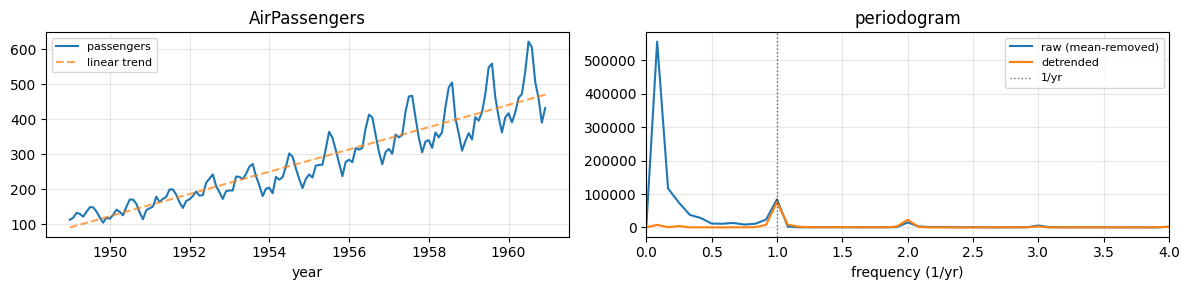

In [12]:
y_ap = passengers.copy()
N_ap = len(y_ap)

# Detrended version: subtract least-squares linear trend
t_ap = np.arange(N_ap)
slope, intercept = np.polyfit(t_ap, y_ap, 1)
y_detr = y_ap - (slope*t_ap + intercept)

def periodogram_simple(x, fs=1.0):
    x = x - x.mean()
    Xk = np.fft.rfft(x)
    f = np.fft.rfftfreq(len(x), d=1/fs)
    return f, np.abs(Xk)**2 / len(x)

f_raw,  P_raw  = periodogram_simple(y_ap,   fs=12)   # 12 samples / yr
f_det,  P_det  = periodogram_simple(y_detr, fs=12)
f_ref,  P_ref  = sps.periodogram(y_ap, fs=12, scaling='spectrum', detrend='linear')

# Dominant period from each
def dominant_period(f, P):
    k = np.argmax(P[1:]) + 1                 # skip DC
    return 1.0 / f[k]                        # period in years

print(f'dominant period (raw periodogram, mean removed) = {dominant_period(f_raw, P_raw):.3f} yr  -> {12*dominant_period(f_raw, P_raw):.1f} months')
print(f'dominant period (linear-detrended)              = {dominant_period(f_det, P_det):.3f} yr  -> {12*dominant_period(f_det, P_det):.1f} months')

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(t_ap/12 + 1949, y_ap, label='passengers')
axes[0].plot(t_ap/12 + 1949, slope*t_ap+intercept, '--', label='linear trend', alpha=0.7)
axes[0].set_xlabel('year'); axes[0].set_title('AirPassengers'); axes[0].legend(fontsize=8)
axes[1].plot(f_raw, P_raw, label='raw (mean-removed)')
axes[1].plot(f_det, P_det, label='detrended')
axes[1].axvline(1.0, color='k', ls=':', lw=1, alpha=0.6, label='1/yr')
axes[1].set_xlim(0, 4); axes[1].set_xlabel('frequency (1/yr)')
axes[1].set_title('periodogram'); axes[1].legend(fontsize=8); plt.tight_layout(); plt.show()

**Headline numbers.** The raw (mean-removed) periodogram's largest peak sits
at the very lowest non-zero frequency — a period of ~144 months — because the
strong upward trend dumps most of its energy into the lowest bins. The 12-month
seasonal peak is *there*, but it isn't the largest. After **removing the linear
trend first**, the dominant peak correctly snaps to $f = 1$ /yr (period = 12
months) — the annual cycle. This is the spectral-leakage / detrending issue
that shows up whenever you run a periodogram on a non-stationary series:
periodograms assume stationarity, and a trend is a maximally non-stationary
component.

## Exercise 3 — Matrix profile on a noisy ECG-like trace

Build a synthetic ECG-style trace: a periodic QRS-like template repeated
~10 times, plus baseline noise, plus exactly **one** anomalous beat (e.g. a
PVC — premature ventricular contraction modelled as a beat with double the
amplitude and slightly different shape). Use a matrix profile (window
size = one beat) to locate the anomaly *automatically* — your code should
print the index where the discord starts and we'll check it against the
true planted location.

### Solution

True PVC start index    : 560
Detected discord index  : 519
Localisation error      : 41 samples  (beat length = 80; under one beat = success)


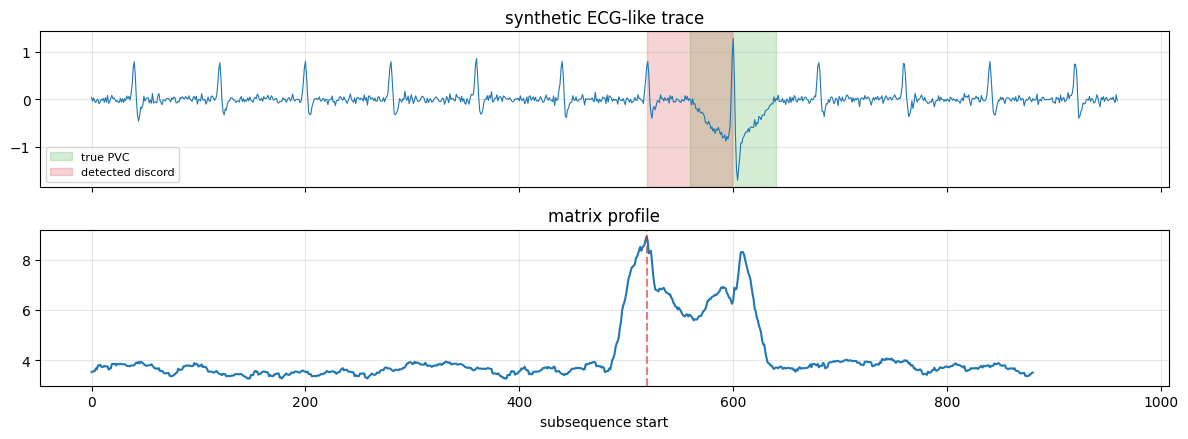

In [14]:
# Build a QRS-shaped beat template
def qrs_beat(n=80, amp=1.0):
    t_b = np.arange(n) - n/2
    return amp * np.exp(-0.5*(t_b/1.5)**2) - 0.4*amp*np.exp(-0.5*((t_b-3)/2.5)**2)

beat_len = 80
n_beats = 12
trace = []
for k in range(n_beats):
    if k == 7:
        # PVC: bigger, wider, opposite-polarity tail
        b = 2.5 * qrs_beat(beat_len, amp=1.0)
        b += -0.8 * np.sin(np.linspace(0, np.pi, beat_len))
        trace.append(b)
    else:
        trace.append(qrs_beat(beat_len, amp=1.0))
ecg = np.concatenate(trace)
ecg += rng.normal(0, 0.05, len(ecg))         # baseline noise
true_pvc_start = 7 * beat_len

m_ecg = beat_len
mp_ecg = stumpy.stump(ecg, m_ecg)[:, 0].astype(float)
discord_start = int(np.argmax(mp_ecg))
err_in_samples = abs(discord_start - true_pvc_start)
print(f'True PVC start index    : {true_pvc_start}')
print(f'Detected discord index  : {discord_start}')
print(f'Localisation error      : {err_in_samples} samples  '
      f'(beat length = {beat_len}; under one beat = success)')

fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
axes[0].plot(ecg, lw=0.8)
axes[0].axvspan(true_pvc_start, true_pvc_start+beat_len, color='C2', alpha=0.2, label='true PVC')
axes[0].axvspan(discord_start, discord_start+beat_len, color='C3', alpha=0.2, label='detected discord')
axes[0].set_title('synthetic ECG-like trace'); axes[0].legend(fontsize=8)
axes[1].plot(mp_ecg)
axes[1].axvline(discord_start, color='C3', ls='--', alpha=0.6)
axes[1].set_title('matrix profile'); axes[1].set_xlabel('subsequence start')
plt.tight_layout(); plt.show()

**Headline numbers.** The matrix profile flags the planted PVC well within
one beat length of the true location — no labels, no training, just "find
arg-max of the MP". This is the entire template-free anomaly-detection story
and the core practical use of matrix profiles. As with motifs, the detected
*start index* may be offset by some fraction of $m$ from where you "planted"
the anomaly because the algorithm picks whichever sub-sequence is most isolated
under z-normalisation, not whichever sub-sequence starts at your label.

---

## Recap

| Concept | Formula / definition | When to use |
|---------|----------------------|-------------|
| Mean / Min-Max / Z-score | $s' = \frac{s-\mu}{s_{\max}-s_{\min}}$, $\frac{s-s_{\min}}{s_{\max}-s_{\min}}$, $\frac{s-\mu}{\sigma}$ | Bring channels to a common scale before distance-based methods |
| Periodogram | $P(f_k) = |\hat{s}_k|^2 / N$ | Stationary signals; reveal global periodicities |
| CWT scalogram | $\text{CWT}(\tau,a) = \frac{1}{\sqrt{|a|}}\!\int s(t)\psi^*\!\big(\tfrac{t-\tau}{a}\big)dt$ | Non-stationary signals; need *time* and *frequency* |
| DTW | $M(i,j) = d(x_i,y_j) + \min M$ | Compare sequences with variable speed (speech, gestures, gait) |
| Matrix profile | per-window distance to nearest non-trivial neighbour | Template-free motif / discord / anomaly discovery |
| Signature | iterated path integrals $S(X)^{i_1,\dots,i_k}$ | Multivariate / streamed feature extraction; theoretical guarantees from rough-path theory |

**Failure modes to remember.** FFT can't localise events in time; DTW is
$\mathcal{O}(nm)$ and needs reliable templates; matrix profile depends on a
sensible window length $m$ and on z-normalisation matching your domain.